# Moore–Spiegel oscillator

The Moore–Spiegel oscillator is a 3-dimensional ODE,

$$
\begin{aligned}
\dot{x}_1 &= x_2, \\
\dot{x}_2 &= x_3, \\
\dot{x}_3 &= -x_3 - (T - R + R x_1^2)\, x_2 - T x_1,
\end{aligned}
$$

where $x_1 = x$, $x_2 = \dot{x}$ and $x_3 = \ddot{x}$, with $R = 20$ and $T = 6$ generating chaotic behaviors. The ground truth is numerically integrated with the 4th-order Runge-Kutta (RK4) method using a time step of $h = 0.01$ s, and the learned models are rolled out autoregressively at the same time step.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'eval':
    os.chdir('..')
sys.path[:0] = ['src', 'eval']
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from eval_MS import load_model
from V_ablation_MS import VARIANTS, main
%matplotlib inline

def show(*names, height=420):
    for name in names:
        im = Image.open(os.path.join(out_dir, name))
        display(im.resize((round(im.width * height / im.height), height)))

Reproducing Figure 6, the ablation study between different energy function parameterization options with trajectory visualizations and statistical properties.

[device] cuda
[eval_MS] caches present, skipping: assets/models/moore_spiegel/noproj
[eval_MS] caches present, skipping: assets/models/moore_spiegel/Vellip_proj
[eval_MS] caches present, skipping: assets/models/moore_spiegel/Vquartic_proj
[eval_MS] caches present, skipping: assets/models/moore_spiegel/Vmlp_proj

=== Unconstrained ===
  dir: assets/models/moore_spiegel/noproj
  V type: ellip, proj_flag=False
Found cached results at assets/models/moore_spiegel/noproj/eval_E29999_results.npz; loading instead of rolling out.
  c^2 = 10000.000 (no projection -> sublevel set is not certified, skipping shell)

=== Quadratic $V$ ===
  dir: assets/models/moore_spiegel/Vellip_proj
  V type: ellip, proj_flag=True
Found cached results at assets/models/moore_spiegel/Vellip_proj/eval_E29999_results.npz; loading instead of rolling out.
  c^2 = 10000.000, n_in_sublevel = 500,000 / 500,000  -> vol_frac = 1.0000
  sublevel pts (V <= c^2, no shell filter) = 500,000

=== Quartic $V$ ===
  dir: assets/mode

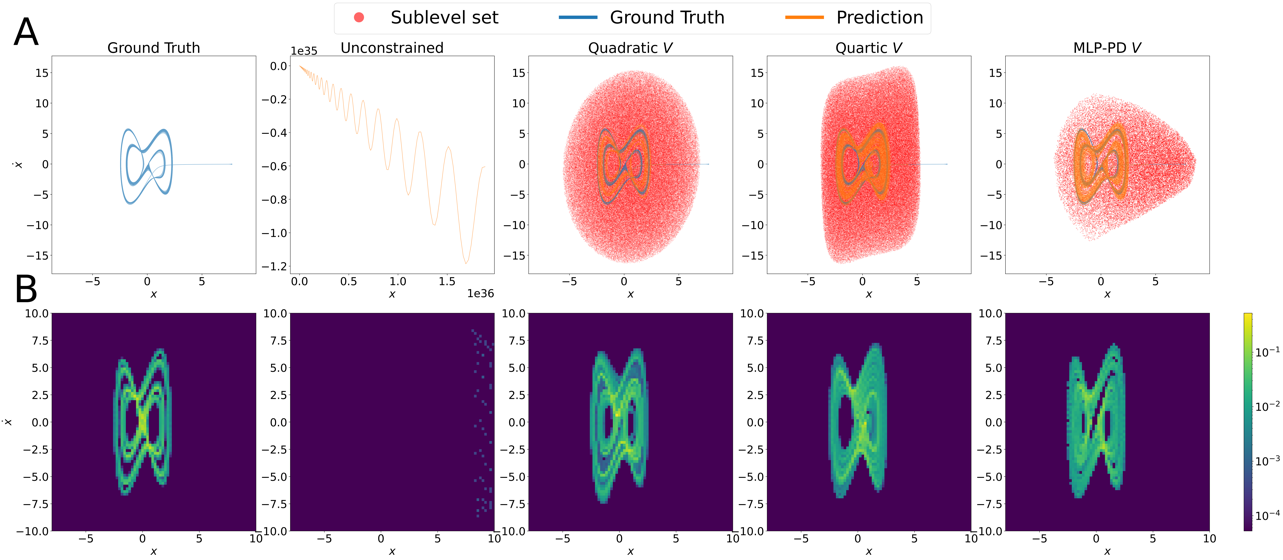

In [2]:
out_dir = 'figures/moore_spiegel'
# Reuse the main function in V_ablation_MS.py to perform evaluation and generate the figure
main(['--out', out_dir])
show('combined_levelset_density_x_xdot.png', height=560)

Reproducing energy time history comparisons under different energy function parameterization options (Figure S5-S7 in SI Appendix).

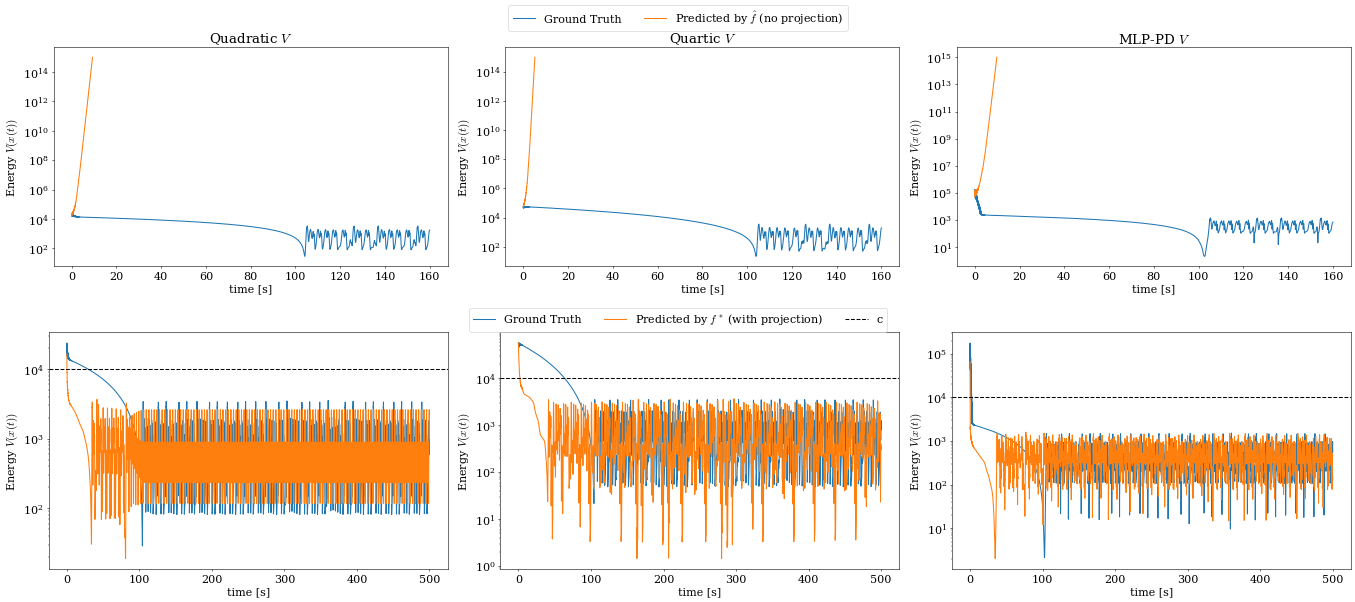

In [3]:
plt.rcdefaults()
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm', 'font.size': 16})
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
folders = ['assets/models/moore_spiegel/' + v[1] for v in VARIANTS]
results = [np.load(f + '/eval_E29999_results.npz') for f in folders]
test_data, preds = results[0]['true'], [r['pred'] for r in results]
fig = plt.figure(figsize=(27, 12), dpi=50, layout='constrained')
subfigs = fig.subfigures(2, 1)
axes = np.array([sf.subplots(1, 3) for sf in subfigs])
t = results[0]['dt'] * np.arange(test_data.shape[1])
top = t <= 160
for ax_hat, ax_star, (title, *_), folder, pred in zip(*axes, VARIANTS[1:], folders[1:], preds[1:]):
    model, _ = load_model(folder + '/models', 'E29999.pt', device, proj_flag=True)
    with torch.no_grad():
        V_GT, V_hat, V_star = [model.V(torch.tensor(x, device=device)).squeeze(1).cpu().numpy()
                               for x in (test_data[0], preds[0][0], pred[0])]
    V_hat[np.argmax(~(V_hat <= 1e15)):] = np.nan
    ax_hat.plot(t[top], V_GT[top], color='tab:blue', label='Ground Truth')
    ax_hat.plot(t[top], V_hat[top], color='tab:orange', label=r'Predicted by $\hat{f}$ (no projection)')
    ax_star.plot(t, V_GT, color='tab:blue', label='Ground Truth')
    ax_star.plot(t, V_star, color='tab:orange', label=r'Predicted by $f^*$ (with projection)')
    ax_star.axhline((model.c ** 2).item(), color='black', ls='--', label='c')
    ax_hat.set_title(title)
    for ax in (ax_hat, ax_star):
        ax.set(yscale='log', xlabel='time [s]', ylabel='Energy $V(x(t))$')
for sf, ax in zip(subfigs, axes[:, 0]):
    sf.legend(*ax.get_legend_handles_labels(), loc='outside upper center', ncol=3)
plt.show()